# Phase estimation: one routine, different operators

**Download Notebook** - {nb-download}`phase_estimation_demo.ipynb`

Quantum phase estimation (QPE) extracts an eigenphase:

$$
U|u\rangle=e^{i\pi\phi}|u\rangle,
\qquad 0\leq\phi<2.
$$

This notebook uses the same `qpe` routine with three controlled-power oracles:

- a single-qubit rotation,
- Trotterized Hamiltonian evolution, and
- a qubitized walk.

## Generic power oracles

`qpe` is generic over the type of register acted on by the oracle. Its power oracle has the form

```python
power_oracle(control: qubit, unitary_regs: UnitaryRegs, power: int) -> None
```

- `UnitaryRegs` can be a qubit array or a struct containing several registers.
- `qpe` requests the required powers; the oracle decides how to implement them.
- The examples use the same `qpe` routine for a powered rotation, repeated Trotter steps and repeated qubitized walks.

Each example also supplies an input state and a phase register. Six phase qubits give a grid spacing of $1/32$. The phase-to-energy conversion depends on the chosen operator.

The examples use [guppy](https://docs.quantinuum.com/guppy/language_guide/language_guide_index.html). The repository default is little endian.


In [1]:
import numpy as np
import zixy.qubit.pauli as zqp
from matplotlib import pyplot as plt
from guppylang import guppy
from guppylang.std.builtins import array, output, dagger
from guppylang.std.angles import angle, pi
from guppylang.std.quantum import (
    qubit, h, ry, crz, measure_array, collect_measurements, discard_array,
)

from guppyalgos.algorithms.phase_estimation import qpe, QubitizationRegs, qubitized_power_oracle
from guppyalgos.utils import (
    qarray, transversal, binary_fraction,
    phase_to_energy_qpe, phase_to_energy_qubitized_qpe,
)

n_phase = 6
n_shots = 128


from guppyalgos.utils.python.analysis import measurement_dataframe


## 1. Read the phase of one qubit

- Choose a rotation whose phase on $|0\rangle$ is known:

$$
U=R_z(-2\pi\phi_0),\qquad U|0\rangle=e^{i\pi\phi_0}|0\rangle,
\qquad \phi_0=0.75.
$$

- The **power oracle** must apply controlled $U^k$. For a rotation, multiply its angle by $k$.

- Prepare the phase register with Hadamards before calling `qpe`; it then applies controlled powers and the inverse QFT.

In [2]:
target_phase = 0.75


@guppy
def rotation_power(control: qubit, qreg: array[qubit, 1], power: int) -> None:
    crz(control, qreg[0], -2 * pi * target_phase * power)

### Build the main circuit

- Allocate the registers, prepare the phase register, and call `qpe` with the rotation oracle.

In [3]:
@guppy
def rotation_qpe() -> None:
    qreg = qarray(1)
    phase_qreg = qarray(n_phase)
    transversal(h, phase_qreg)
    qpe(phase_qreg, qreg, rotation_power)
    output("phase", collect_measurements(measure_array(phase_qreg)))
    discard_array(qreg)

### Run and read the phase

- Sample the circuit and decode the measured phase with `measurement_dataframe`.

In [5]:
rotation_counts = (
    rotation_qpe.emulator(n_phase + 1).with_seed(5).with_shots(n_shots)
    .run().register_counts()["phase"]
)
rotation_results = measurement_dataframe(rotation_counts)
rotation_phases = rotation_results.set_index("phase")["empirical_probability"].to_dict()
assert rotation_phases == {target_phase: 1.0} 
print(rotation_results)


  bitstring  counts  phase  empirical_probability
0    000110     128   0.75                    1.0


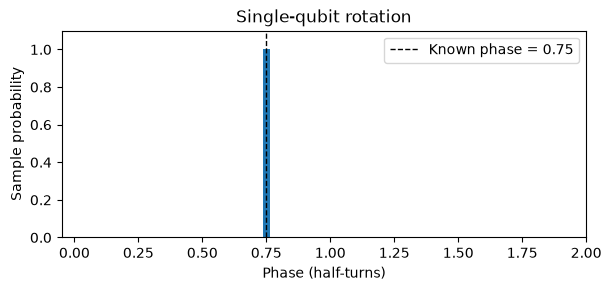

In [6]:
fig, axis = plt.subplots(figsize=(6, 2.8), layout="constrained")
axis.bar(list(rotation_phases), list(rotation_phases.values()), width=0.8 * (2 / 2**n_phase))
axis.axvline(target_phase, color="black", linestyle="--", linewidth=1,
             label="Known phase = 0.75")
axis.set(title="Single-qubit rotation", xlabel="Phase (half-turns)",
         ylabel="Sample probability", xlim=(-0.05, 2), ylim=(0, 1.1))
axis.legend()
plt.show()

- The phase lies exactly on the grid, so the ideal simulator returns it every time. With a superposition of eigenstates, repeated runs instead sample their phases according to the input's overlaps.

- `measurement_dataframe` decodes the raw register counts into phases and empirical probabilities; the following examples use the same helper.

## 2. Estimate an energy with Trotterized evolution

Use the noncommuting Hamiltonian

$$
H=\tfrac12X+\tfrac12Z,\qquad E_0=-1/\sqrt2.
$$

- Its ground-state energy is $E_0=-1/\sqrt2$.
- Its known ground state is prepared with $R_y(-3\pi/4)|0\rangle$.
- For larger problems, finding a state with useful eigenstate overlap is a separate task; QPE does not prepare the ground state.


In [ ]:
from guppyalgos.algorithms.time_evolution.trotter import (
    ham_sim_trotter, trotter_first_order, cntrl_trotter_first_order,
)

hamiltonian = zqp.RealTermSum.from_str("(0.5, X0), (0.5, Z0)", 1)
controlled_step = cntrl_trotter_first_order(hamiltonian, 1)
total_time = 1.0
n_steps = 16
exact_energy = -1 / np.sqrt(2)

# Full, uncontrolled evolution over total_time.
simulate = ham_sim_trotter(
    trotter_first_order(hamiltonian, 1),
    n_steps=n_steps, time_step=total_time / n_steps, n_state_qubits=1,
)
simulate.compile_function()

### Prepare the state and controlled evolution

Split $t=1$ into $r=16$ first-order Trotter steps:

$$
U(t)\approx
\left[\prod_j e^{-i\pi(t/r)h_j/2}\right]^r.
$$

- `ham_sim_trotter` builds the complete uncontrolled evolution.
- QPE needs controlled evolution, so `trotter_power` repeats `cntrl_trotter_first_order`.
- A requested power repeats the complete 16-step simulation.

In [ ]:
@guppy
def prepare_ground(qreg: array[qubit, 1]) -> None:
    ry(qreg[0], angle(-0.75))  # Angles are in half-turns.


@guppy
def trotter_power(control: qubit, qreg: array[qubit, 1], power: int) -> None:
    for _ in range(power * n_steps):
        controlled_step(control, qreg, total_time / n_steps)

### Build the main circuit

- Pass the prepared system register and Trotter oracle to the same `qpe` routine.

In [ ]:
@guppy
def trotter_qpe() -> None:
    qreg = qarray(1)
    prepare_ground(qreg)
    phase_qreg = qarray(n_phase)
    transversal(h, phase_qreg)
    qpe(phase_qreg, qreg, trotter_power)
    output("phase", collect_measurements(measure_array(phase_qreg)))
    discard_array(qreg)

### Convert the measured phase to energy

For an energy eigenstate, the simulated evolution contributes

$$
U(t)|E\rangle\approx e^{-i\pi tE/2}|E\rangle.
$$

QPE reports $e^{i\pi\phi}$, so

$$
\phi=-\frac{tE}{2}\pmod 2.
$$

For the negative-energy branch at $t=1$, use $E=-2\phi$. The result is

| Quantity | Exact | QPE result |
| --- | ---: | ---: |
| Phase resolution | -- | $1/32$ |
| Phase $\phi$ | $1/(2\sqrt2)=0.353553\ldots$ | $11/32=0.34375$ |
| Energy $E=-2\phi$ | $-1/\sqrt2=-0.707107\ldots$ | $-0.6875$ |

Choose the evolution time and energy range so the energy branch can be recovered without ambiguity from phase wrapping.

In [4]:
trotter_counts = (
    trotter_qpe.emulator(n_phase + 1).with_seed(5).with_shots(n_shots)
    .run().register_counts()["phase"]
)
trotter_results = measurement_dataframe(trotter_counts)
trotter_phases = trotter_results.set_index("phase")["empirical_probability"].to_dict()
trotter_energy = lambda phase: phase_to_energy_qpe(phase, total_time)
dominant_phase = max(trotter_phases, key=trotter_phases.get)
trotter_results["energy"] = trotter_results["phase"].map(trotter_energy)
print(trotter_results.head(5).to_string(index=False, float_format=lambda value: f"{value:.4f}"))


bitstring  counts  phase  empirical_probability  energy
   110100      81 0.3438                 0.6328 -0.6875
   001100      26 0.3750                 0.2031 -0.7500
   010100       6 0.3125                 0.0469 -0.6250
   101100       5 0.4062                 0.0391 -0.8125
   010010       2 0.5625                 0.0156 -1.1250


- There are two sources of error: the finite phase grid and the Trotter approximation.

- More phase qubits refine the grid; more Trotter steps improve the simulated evolution.

- QPE measures the implemented unitary, so refining the grid alone does not remove Trotter error.

## 3. Estimate the same energy with qubitization

Instead of approximating time evolution, encode $H/\lambda$ with LCU. For this Hamiltonian,

$$
B=P^\dagger SP,\qquad \lambda=\sum_j|a_j|=1.
$$

`PREPARE` loads the LCU weights, `SELECT` applies the indexed Pauli term, and `UNPREPARE` completes the block encoding.

In [ ]:
from guppyalgos.algorithms.block_encoding.lcu import (
    LCUCntrl, LCUData, build_cntrl_single_cntrl_select,
)
from guppyalgos.algorithms.block_encoding.qubitization import QubitizationCntrl
from guppyalgos.algorithms.state_preparation import multiplexor_prep
from guppyalgos.primitives.subroutines.reflection import ReflectionCntrl
from guppyalgos.primitives.gate_decompositions.cnx.cnx import cnx

data = LCUData.from_hamiltonian(hamiltonian)
prepare = multiplexor_prep(data.amplitudes)
controlled_select = build_cntrl_single_cntrl_select(data)

### Define the controlled walk

Build the walk by following the LCU block with a reflection about the zero preparation state:

$$
W=(I-2|0\rangle\langle0|)B.
$$

- The two reflections act as a rotation in each invariant subspace.
- Each energy therefore produces conjugate walk eigenvalues $e^{i\theta}$ and $e^{-i\theta}$.
- Their QPE phases are $\theta/\pi$ and $2-\theta/\pi$.
- `walk_power` exposes repeated controlled walks through the QPE oracle interface.

In [ ]:
@guppy
def unprepare(prep_qreg: array[qubit, 1]) -> None:
    with dagger:
        prepare(prep_qreg)


@guppy
def controlled_walk(
    control: qubit, prep_qreg: array[qubit, 1], qreg: array[qubit, 1],
) -> None:
    QubitizationCntrl(
        LCUCntrl(prepare, controlled_select, unprepare), ReflectionCntrl[1](cnx)
    ).compose(control, prep_qreg, qreg)


@guppy
def walk_power(
    control: qubit, regs: QubitizationRegs[1, array[qubit, 1]], power: int,
) -> None:
    qubitized_power_oracle(control, regs, power, controlled_walk)

### Build the main circuit

- `QubitizationRegs` groups the LCU preparation qubit with the system register.
- The QPE interface is unchanged: pass the phase register, grouped target registers and power oracle to `qpe`.

In [ ]:
@guppy
def walk_qpe() -> None:
    qreg = qarray(1)
    prepare_ground(qreg)
    regs = QubitizationRegs(qarray(1), qreg)
    phase_qreg = qarray(n_phase)
    transversal(h, phase_qreg)
    qpe(phase_qreg, regs, walk_power)
    output("phase", collect_measurements(measure_array(phase_qreg)))
    discard_array(regs.prep)
    discard_array(regs.target)

### Convert walk phases to energy

QPE now measures a **walk phase**. Convert either member of the conjugate pair with

$$
E=-\lambda\cos(\pi\phi).
$$

- Here $\lambda=1$.
- Decode both peaks and convert each phase to its Hamiltonian energy.

In [5]:
walk_counts = (
    walk_qpe.emulator(n_phase + 2).with_seed(5).with_shots(n_shots)
    .run().register_counts()["phase"]
)
walk_results = measurement_dataframe(walk_counts)
walk_phases = walk_results.set_index("phase")["empirical_probability"].to_dict()
walk_energy = lambda phase: phase_to_energy_qubitized_qpe(phase, data.l1_norm)
assert set(walk_phases) <= {0.25, 1.75}
for phase in walk_phases:
    np.testing.assert_allclose(walk_energy(phase), exact_energy, atol=1e-10)
walk_results["energy"] = walk_results["phase"].map(walk_energy)
print(walk_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))


bitstring  counts  phase  empirical_probability  energy
   000100      75 0.2500                 0.5859 -0.7071
   000111      53 1.7500                 0.4141 -0.7071


## From observed peaks to energy

- The horizontal axes below show **phase**, not energy. Convert each peak using the operator that QPE measured:

| Operator | Observed phase (half-turns) | Conversion | Estimated energy |
| :-- | :-- | :-- | :-- |
| Trotterized evolution, $t=1$ | $0.34375$ (dominant bin) | $-2\times0.34375$ | $-0.687500$ |
| Qubitized walk, $\lambda=1$ | $0.25$ | $-\cos(\pi/4)$ | $-0.707107$ |
| Same walk, second peak | $1.75$ | $-\cos(7\pi/4)$ | $-0.707107$ |

- The exact ground energy is $-1/\sqrt2\approx-0.707107$. Both walk peaks lie exactly on the phase grid and recover it.
- The input overlaps both walk eigenstates; finite sampling makes their peak heights slightly different.
- The ideal evolution phase, $0.353553\ldots$, lies between bins. Its dominant measured bin gives an energy about $0.0196$ above the exact value. With 16 Trotter steps, this gap is mainly phase resolution.
- The check below allows for both grid resolution and Trotter error. Increasing the phase-register size reduces the grid spacing; increasing the step count reduces Trotter error.


In [6]:
from guppyalgos.testing import get_unitary

phase_resolution = 2 / 2**n_phase
exact_phase = np.mod(-total_time * exact_energy / 2, 2)

# Find the Trotter eigenphase closest to the exact ground-state phase.
implemented_unitary = get_unitary(simulate, 1)
implemented_phases = np.mod(
    np.angle(np.linalg.eigvals(implemented_unitary)) / np.pi, 2,
)
trotter_phase = min(
    implemented_phases, key=lambda phase: abs(phase - exact_phase),
)
nearest_phase_bin = round(trotter_phase / phase_resolution) * phase_resolution
np.testing.assert_allclose(dominant_phase, nearest_phase_bin)

# Allow for Trotter error and one phase-bin width.
trotter_error = abs(trotter_energy(trotter_phase) - exact_energy)
np.testing.assert_allclose(
    trotter_energy(dominant_phase), exact_energy,
    atol=phase_resolution / total_time + trotter_error, rtol=0,
)

# Both qubitized peaks map directly to the exact energy.
qubitized_energies = [walk_energy(phase) for phase in walk_phases]
np.testing.assert_allclose(qubitized_energies, exact_energy, atol=1e-10)
print(f"Trotter: {trotter_energy(dominant_phase):.6f}")
print(f"Qubitized: {walk_energy(next(iter(walk_phases))):.6f} (both peaks)")
print(f"Exact: {exact_energy:.6f}")


Trotter: -0.687500
Qubitized: -0.707107 (both peaks)
Exact: -0.707107


## What changed?

| Example | Controlled operation | Readout |
| :-- | :-- | :-- |
| One-qubit rotation | Multiply a rotation angle by the requested power. | Phase $\phi$. |
| Trotterized simulation | Repeat the controlled Trotter step. | Energy from $-2\phi/t$, on the chosen phase branch. |
| Qubitization | Repeat a controlled LCU-and-reflection walk. | Energy from $-\lambda\cos(\pi\phi)$. |

- These are different oracles for canonical QPE. Each run uses $m$ phase qubits and asks for powers $1,2,\ldots,2^{m-1}$. The two histograms below use the same Hamiltonian and ground-state input. Trotterized evolution has one dominant energy phase; the reflected walk has two conjugate phases for that same energy.

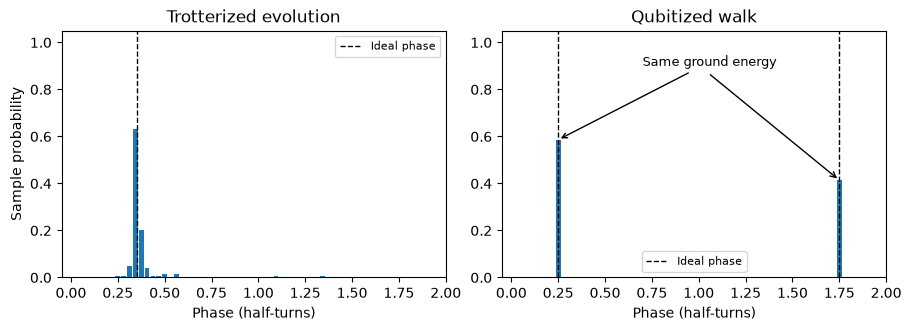

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")
cases = [
    ("Trotterized evolution", trotter_phases, [-exact_energy * total_time / 2]),
    ("Qubitized walk", walk_phases, [0.25, 1.75]),
]
for axis, (title, probabilities, targets) in zip(axes, cases):
    axis.bar(list(probabilities), list(probabilities.values()), width=0.8 * (2 / 2**n_phase))
    for i, phase in enumerate(targets):
        axis.axvline(phase, color="black", linestyle="--", linewidth=1,
                     label="Ideal phase" if i == 0 else None)
    axis.set(title=title, xlabel="Phase (half-turns)", xlim=(-0.05, 2), ylim=(0, 1.05))
    axis.legend(fontsize=8)
axes[0].set_ylabel("Sample probability")
axes[1].annotate("Same ground energy", xy=(0.25, walk_phases[0.25]),
                 xytext=(0.7, 0.9), arrowprops={"arrowstyle": "->"}, fontsize=9)
axes[1].annotate("", xy=(1.75, walk_phases[1.75]),
                 xytext=(1.05, 0.87), arrowprops={"arrowstyle": "->"})
plt.show()

## Go further: THC phase estimation

- The {doc}`advanced THC example </examples/phase_estimation/thc_qpe>` builds a chemistry-oriented controlled LCU using alias-sampling PREPARE, QROM and orbital rotations.

- It retains the alias workspace across walk steps and reflects its all-zero state; the SELECT record is uncomputed before each reflection.

- It is an integration/type-checking example; the full circuit is too large for practical statevector simulation.

- Continue with {doc}`canonical QPE </examples/phase_estimation/canonical_phase_estimation>`, {doc}`Trotterized QPE </examples/phase_estimation/zixy_phase_estimation>`, or {doc}`qubitized QPE </examples/phase_estimation/qubitized_phase_estimation>` for larger examples. The library also provides `iqpe` to reverse canonical QPE using inverse controlled powers, and `hadamard_test` as a one-control-qubit phase-sensitive primitive.